### https://www.kaggle.com/competitions/drawing-with-llms

In [10]:
import kagglehub
import pandas as pd
import sys
from IPython.display import SVG
sys.path.append('./utils')

### Topic Loader from txt batch files

In [62]:
import xml.etree.ElementTree as ET
import re

def high_score_svg_resize(
    svg_code: str,
    padding_ratio: float = 0.08,  # Padding for the border area relative to original size
    min_stroke: float = 1.5,
    max_stroke: float = 16,
) -> str:
    """
    Enhances the SVG code by adjusting the stroke width, font size, scaling it,
    and adding a solid black border (padding area), preserving the original aspect ratio.

    Parameters:
    svg_code (str): The original SVG code.
    padding_ratio (float): Padding to apply around the SVG (default 0.08). This is the area
                           reserved for the solid black border, relative to the original largest dimension.
    min_stroke (float): Minimum stroke width (default 1.5).
    max_stroke (float): Maximum stroke width (default 16).

    Returns:
    str: The enhanced SVG code with a solid black border, preserving the original aspect ratio.
    """
    root = ET.fromstring(svg_code)

    # Define structural tags early
    structural_tags = {
        ET.QName("http://www.w3.org/2000/svg", ln)
        for ln in ['defs', 'style', 'title', 'metadata', 'script']
    }

    viewBox = root.get("viewBox")
    if viewBox is None:
        # Attempt to infer viewBox from width/height if available
        width = root.get("width")
        height = root.get("height")
        if width and height:
            try:
                vb_w = float(re.findall(r'\d+\.?\d*', width)[0])
                vb_h = float(re.findall(r'\d+\.?\d*', height)[0])
                viewBox = f"0 0 {vb_w} {vb_h}"
                root.set("viewBox", viewBox)
            except (ValueError, IndexError):
                viewBox = "0 0 96 96"  # Default if parsing fails
                root.set("viewBox", viewBox)
        else:
            viewBox = "0 0 96 96"  # Default if no viewBox, width, or height
            root.set("viewBox", viewBox)

    vb_x, vb_y, vb_w, vb_h = map(float, viewBox.strip().split())

    # Determine the reference size for proportional calculations (the larger dimension)
    original_ref_size = max(vb_w, vb_h)
    if original_ref_size <= 0: # Handle case where viewBox is invalid
        original_ref_size = 100 # Default reference size

    # Calculate padding relative to the original largest dimension
    total_padding_on_one_side = padding_ratio * original_ref_size

    # Calculate the new canvas dimensions including the padding
    new_canvas_width = vb_w + 2 * total_padding_on_one_side
    new_canvas_height = vb_h + 2 * total_padding_on_one_side

    # Calculate translation to position the original content within the padded area
    content_translate_x = total_padding_on_one_side - vb_x
    content_translate_y = total_padding_on_one_side - vb_y

    # Create a group for the original SVG content
    g_inner = ET.Element("g")
    transform_inner = f"translate({content_translate_x:.2f},{content_translate_y:.2f})"
    g_inner.set("transform", transform_inner)

    # Remove structural elements from the main root and move content to inner group
    children_to_move = []
    for child in list(root):
        qname = ET.QName(child.tag)
        if qname not in structural_tags:
            children_to_move.append(child)

    for child in children_to_move:
        g_inner.append(child)
        root.remove(child)

    # Create the new root element with the updated dimensions and viewBox
    new_root = ET.Element("svg", xmlns="http://www.w3.org/2000/svg")
    new_root.set("width", str(round(new_canvas_width)))
    new_root.set("height", str(round(new_canvas_height)))
    new_root.set("viewBox", f"0 0 {round(new_canvas_width)} {round(new_canvas_height)}")
    # Preserve aspect ratio is now handled by the calculated new canvas dimensions and viewBox

    # --- Add Solid Black Border ---
    black_border_rect = ET.Element("rect")
    black_border_rect.set("x", "0")
    black_border_rect.set("y", "0")
    black_border_rect.set("width", str(round(new_canvas_width)))
    black_border_rect.set("height", str(round(new_canvas_height)))
    black_border_rect.set("fill", "#000000") # Fill the entire new canvas with black
    black_border_rect.set("stroke", "none")
    new_root.append(black_border_rect)

    # Add a white rectangle behind the inner content to make it opaque and cover the black
    # in the content area. The original content will be placed on top of this.
    white_background_rect = ET.Element("rect")
    white_background_rect.set("x", str(total_padding_on_one_side))
    white_background_rect.set("y", str(total_padding_on_one_side))
    white_background_rect.set("width", str(round(vb_w))) # Use original content dimensions
    white_background_rect.set("height", str(round(vb_h))) # Use original content dimensions
    white_background_rect.set("fill", "#FFFFFF") # Fill with white
    white_background_rect.set("stroke", "none")
    new_root.append(white_background_rect)


    # Append the transformed inner content group
    new_root.append(g_inner)

    # Adjust stroke-width and font-size to fit the new relative scale
    def clamp_visuals(el):
        for attr in ("stroke-width", "font-size"):
            if attr in el.attrib:
                try:
                    original = float(re.findall(r'\d+\.?\d*', el.attrib[attr])[0])
                    clamped = max(min_stroke, min(max_stroke, original))
                    el.attrib[attr] = f"{clamped:.2f}"
                except (ValueError, IndexError):
                    pass
        for child in el:
            clamp_visuals(child)

    # Apply clamping to the inner content group
    clamp_visuals(g_inner)

    # Return the XML as a string
    return ET.tostring(new_root, encoding="unicode")

In [14]:
import sys
sys.path.append('./utils')
from siglip_class import SVGMetricEvaluator
from aesthetic_evaluator import AestheticEvaluator

In [3]:
from concurrent.futures import ThreadPoolExecutor, TimeoutError
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
# Initialize evaluator
evaluator = SVGMetricEvaluator()
aes_eval = AestheticEvaluator()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
def safe_svg_metric(prompt, svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(evaluator.svg_metric, prompt, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

def safe_aes_eval(svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(aes_eval.get_score, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

In [43]:
df=pd.read_csv('./drawing-with-llms/train_filtered_1_batch_gpt4.csv')
df=df.iloc[:100]

0.43692469596862793


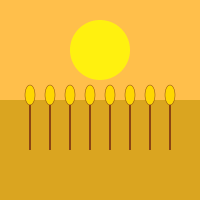

In [66]:
print(safe_aes_eval(df['clean_svg'].iloc[0]))
SVG(df['clean_svg'].iloc[0])

0.4739126205444336


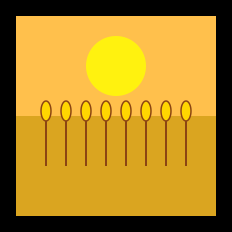

In [67]:
print(safe_aes_eval(high_score_svg_resize(df['clean_svg'].iloc[0])))
SVG(high_score_svg_resize(df['clean_svg'].iloc[0]))

In [64]:
# Apply with tqdm and timeout-aware function
df['aes_score'] = df.progress_apply(
    lambda row: safe_aes_eval(high_score_svg_resize(row['clean_svg'])), axis=1
)

100%|█████████████████████████████████████████| 100/100 [00:09<00:00, 10.19it/s]


In [65]:
df['aes_score'].mean()

0.44000018548965464

In [ ]:
# Apply with tqdm and timeout-aware function
df['aes_score'] = df.progress_apply(
    lambda row: safe_aes_eval(row['clean_svg']), axis=1
)

### Async version is actually slower, why?

In [51]:
df['clean_svg'].iloc[1]

'<svg viewBox="0 0 200 100" width="200" height="100" xmlns="http://www.w3.org/2000/svg">\n  <!-- Sky -->\n  <rect x="0" y="0" width="200" height="100" fill="skyblue" />\n  \n  <!-- Mountains -->\n  <polygon points="30,80 70,30 110,80" fill="white" stroke="gray" stroke-width="1" />\n  <polygon points="90,80 130,40 170,80" fill="white" stroke="gray" stroke-width="1" />\n  \n  <!-- Ground -->\n  <rect x="0" y="80" width="200" height="20" fill="lightgray" />\n</svg>'